# Notebook for testing

By Kenneth Burchfiel

Released under the MIT license

In [1]:
import pandas as pd
import plotly.express as px

# Setting rendering options

These options improve the readability and appearance of the output when saved as a PDF file.

In [2]:
render_for_printing = False

# The following code is based on:
# https://plotly.com/python/renderers/
if render_for_printing == True:
    import plotly.io as pio
    pio.renderers.default='svg'
    pd.set_option('display.max_columns', 8)
    
    

In [3]:
offline_import = True

if offline_import == True: # In this case, the source data will get read 
    # in locally.
    print("Importing source data from local .csv files.")
    df_curr_enrollment = pd.read_csv(
        '../../Appendix/curr_enrollment.csv')
    df_survey_results = pd.read_csv(
        '../../Appendix/survey_results.csv')
else:
    print("Downloading source data from an online source.")
    df_curr_enrollment = pd.read_csv(
        'https://raw.githubusercontent.com/kburchfiel/\
pfn/main/Appendix/curr_enrollment.csv')
    df_survey_results = pd.read_csv('https://raw.githubusercontent.com/\
kburchfiel/pfn/main/Appendix/survey_results.csv')

Importing source data from local .csv files.


In [4]:
def improve_col_display(df):
    '''This function replaces underscores in column names with spaces
    and also converts them to title space, thus improving their
    appearance within chart titles. 
    Since some values (e.g. 'ID') are best capitalized rather than
    converted to title case, the function also includes a 
    df.rename() col. This can be expanded as needed to address any
    issues caused by the title case conversion.
    '''
    df.columns = [column.replace('_', ' ').title() 
                  for column in df.columns]
    df.rename(
        columns = {'Student Id':'Student ID'}, inplace = True)

In [5]:
improve_col_display(df_survey_results)
improve_col_display(df_curr_enrollment)

In [6]:
df_survey_results['Count'] = 1

improve_col_display(df_curr_enrollment)

df_curr_enrollment['Count'] = 1
df_curr_enrollment.head()

,First Name,Last Name,Gender,Matriculation Year,...,Class Of,Level,Level For Sorting,Count
0,Danielle,Wilson,F,2020,...,2024,Fr,0,1
1,Anna,Smith,F,2020,...,2024,Fr,0,1
2,Ann,Baker,F,2020,...,2024,Fr,0,1
3,Jennifer,Costa,F,2020,...,2024,Fr,0,1
4,Brenda,Wood,F,2020,...,2024,Fr,0,1


In [7]:
cols_to_exclude = ['Date of Birth', 'First Name', 'Last Name', 
                   'Student ID']
comparison_list = list(
    set(df_curr_enrollment.columns) - set(cols_to_exclude))
comparison_list

['College',
 'Count',
 'Gender',
 'Matriculation Year',
 'Matriculation Number',
 'Class Of',
 'Level',
 'Level For Sorting',
 'Date Of Birth']

In [8]:
df_curr_enrollment.columns

Index(['First Name', 'Last Name', 'Gender', 'Matriculation Year',
       'Matriculation Number', 'Student ID', 'Date Of Birth', 'College',
       'Class Of', 'Level', 'Level For Sorting', 'Count'],
      dtype='object')

In [9]:
df_survey_results_extra_data = df_survey_results.drop(
    'Count', axis = 1).merge(
    df_curr_enrollment, on = 'Student ID', how = 'left')[
['Starting Year', 'Season', 'Score', 'Gender', 'Matriculation Year',
 'College', 'Class Of', 'Level', 'Level For Sorting', 'Count']]
df_survey_results_extra_data


,Starting Year,Season,Score,Gender,...,Class Of,Level,Level For Sorting,Count
0,2023,Fall,88,F,...,2024,Fr,0,1
1,2023,Fall,37,F,...,2024,Fr,0,1
2,2023,Fall,54,F,...,2024,Fr,0,1
3,2023,Fall,56,F,...,2024,Fr,0,1
4,2023,Fall,77,F,...,2024,Fr,0,1
...,...,...,...,...,...,...,...,...,...
32763,2023,Spring,90,M,...,2027,Se,3,1
32764,2023,Spring,100,M,...,2027,Se,3,1
32765,2023,Spring,89,M,...,2027,Se,3,1
32766,2023,Spring,64,M,...,2027,Se,3,1


In [10]:
df_survey_results_extra_data.columns

Index(['Starting Year', 'Season', 'Score', 'Gender', 'Matriculation Year',
       'College', 'Class Of', 'Level', 'Level For Sorting', 'Count'],
      dtype='object')

In [11]:
df_curr_enrollment['Level'].value_counts()

Level
Se    5443
Ju    3999
So    3653
Fr    3289
Name: count, dtype: int64

I ended up not needing the following function, as dash-pivottable also accepts a list of dictionaries--and DataFrames can easily be converted into this format via `df_curr_enrollment.to_dict(orient = 'records')`.

In [12]:
filter_tuple_list = [
    ('College', 
     ['STC', ]),
    ('Level',['Fr','Se'])]
filter_tuple_list

[('College', ['STC']), ('Level', ['Fr', 'Se'])]

In [13]:
df_survey_results_extra_data

,Starting Year,Season,Score,Gender,...,Class Of,Level,Level For Sorting,Count
0,2023,Fall,88,F,...,2024,Fr,0,1
1,2023,Fall,37,F,...,2024,Fr,0,1
2,2023,Fall,54,F,...,2024,Fr,0,1
3,2023,Fall,56,F,...,2024,Fr,0,1
4,2023,Fall,77,F,...,2024,Fr,0,1
...,...,...,...,...,...,...,...,...,...
32763,2023,Spring,90,M,...,2027,Se,3,1
32764,2023,Spring,100,M,...,2027,Se,3,1
32765,2023,Spring,89,M,...,2027,Se,3,1
32766,2023,Spring,64,M,...,2027,Se,3,1


In [14]:
for pair in filter_tuple_list:
    df_survey_results_extra_data.query(
        f"`{pair[0]}` in {pair[1]}", inplace = True)
df_survey_results_extra_data

,Starting Year,Season,Score,Gender,...,Class Of,Level,Level For Sorting,Count
0,2023,Fall,88,F,...,2024,Fr,0,1
2,2023,Fall,54,F,...,2024,Fr,0,1
3,2023,Fall,56,F,...,2024,Fr,0,1
15,2023,Fall,73,F,...,2024,Fr,0,1
17,2023,Fall,51,F,...,2024,Fr,0,1
...,...,...,...,...,...,...,...,...,...
32738,2023,Spring,75,M,...,2027,Se,3,1
32742,2023,Spring,75,M,...,2027,Se,3,1
32749,2023,Spring,81,M,...,2027,Se,3,1
32752,2023,Spring,54,M,...,2027,Se,3,1


In [15]:
def df_to_lol(df):
    '''Converts a DataFrame (passed to df) to a list of lists (or 'lol') 
    that can be used as the data argument when initializing 
    a dash_pivottable.PivotTable().'''
    dict_df = (
    df.copy().to_dict(orient='split'))
    lol = dict_df['data'].copy()
    lol.insert(
        0, dict_df['columns'])
    return lol
    

In [16]:
df_simple_enrollment_pivot = df_curr_enrollment.pivot_table(
    index = ['College', 'Level For Sorting', 'Level'],
    values = 'Count', aggfunc = 'sum').reset_index()
df_simple_enrollment_pivot.head()


,College,Level For Sorting,Level,Count
0,STB,0,Fr,797
1,STB,1,So,975
2,STB,2,Ju,1084
3,STB,3,Se,1309
4,STC,0,Fr,997


In [17]:
df_enrollment_by_college = df_curr_enrollment.pivot_table(
    index = ['College'],
    values = 'Count', aggfunc = 'sum').reset_index()
df_enrollment_by_college

,College,Count
0,STB,4165
1,STC,3670
2,STL,3729
3,STM,4820


In [18]:
df_enrollment_by_level = df_curr_enrollment.pivot_table(
    index = ['Level For Sorting', 'Level'],
    values = 'Count', aggfunc = 'sum').reset_index()
df_enrollment_by_level

,Level For Sorting,Level,Count
0,0,Fr,3289
1,1,So,3653
2,2,Ju,3999
3,3,Se,5443


In [19]:
fig_enrollment_by_college = px.bar(df_enrollment_by_college, 
       x = 'College', y = 'Count', color = 'College',
      text_auto = '.0f',
      title = 'NVCU Enrollment by College')
fig_enrollment_by_college_html = fig_enrollment_by_college.write_html(
    'test_image.html')
print(fig_enrollment_by_college_html)

None


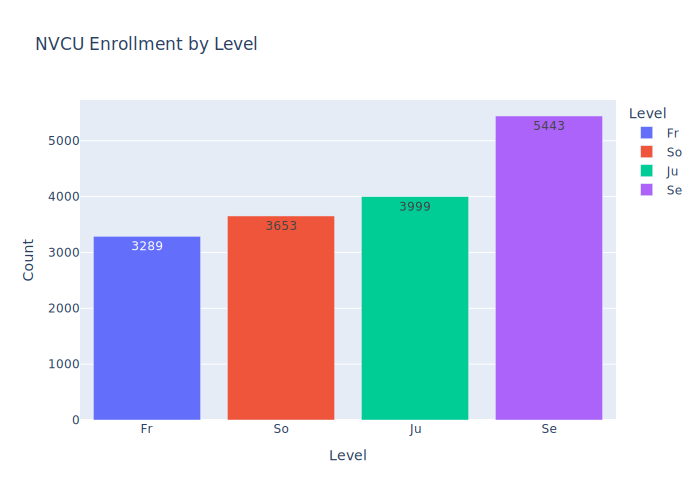

In [20]:
fig_enrollment_by_level = px.bar(df_enrollment_by_level, 
       x = 'Level', y = 'Count', color = 'Level',
      text_auto = '.0f',
      title = 'NVCU Enrollment by Level')
fig_enrollment_by_level

In [21]:
df_curr_enrollment['College'].unique()

array(['STC', 'STM', 'STL', 'STB'], dtype=object)

In [22]:
df_curr_enrollment['All Students'] = 'All Students'
df_total_enrollment = df_curr_enrollment.pivot_table(
    index = ['All Students'],
    values = 'Count', aggfunc = 'sum').reset_index()
df_total_enrollment

,All Students,Count
0,All Students,16384


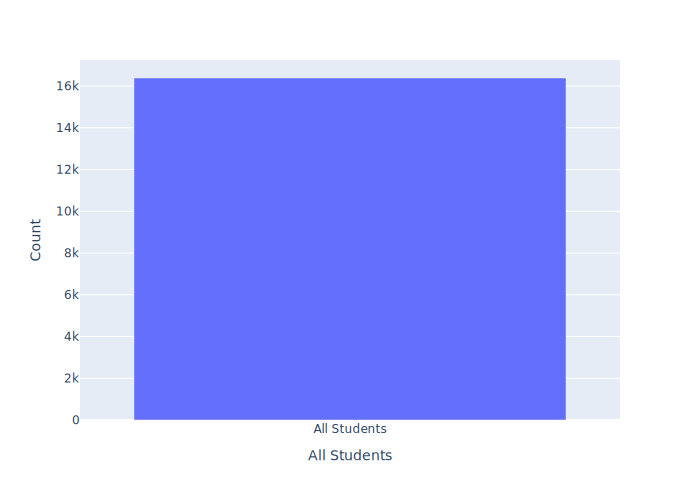

In [23]:
px.bar(df_total_enrollment,
       x = 'All Students', y = 'Count')

In [24]:
df_simple_enrollment_pivot = df_curr_enrollment.pivot_table(
    index = ['College', 'Level For Sorting', 'Level'],
    values = 'Count', aggfunc = 'sum').reset_index()
df_simple_enrollment_pivot['College/Level'] = (
    df_simple_enrollment_pivot['College'] 
    + '/' + df_simple_enrollment_pivot['Level'])
df_simple_enrollment_pivot.head()


,College,Level For Sorting,Level,Count,College/Level
0,STB,0,Fr,797,STB/Fr
1,STB,1,So,975,STB/So
2,STB,2,Ju,1084,STB/Ju
3,STB,3,Se,1309,STB/Se
4,STC,0,Fr,997,STC/Fr


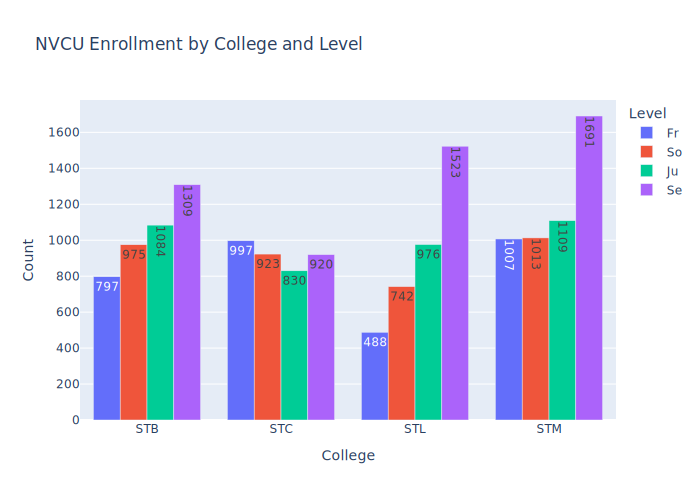

In [25]:
fig_simple_enrollment = px.bar(df_simple_enrollment_pivot, 
       x = 'College', y = 'Count', color = 'Level',
      barmode = 'group',
      text_auto = '.0f',
      title = 'NVCU Enrollment by College and Level')
fig_simple_enrollment

## Additional chart(s) for fixed dashboard:

In [26]:
df_enrollment_by_college_and_level = df_curr_enrollment.pivot_table(
    index = ['College', 'Level For Sorting', 'Level'],
    values = 'Count', aggfunc = 'sum').reset_index()
df_enrollment_by_college_and_level.head()

,College,Level For Sorting,Level,Count
0,STB,0,Fr,797
1,STB,1,So,975
2,STB,2,Ju,1084
3,STB,3,Se,1309
4,STC,0,Fr,997


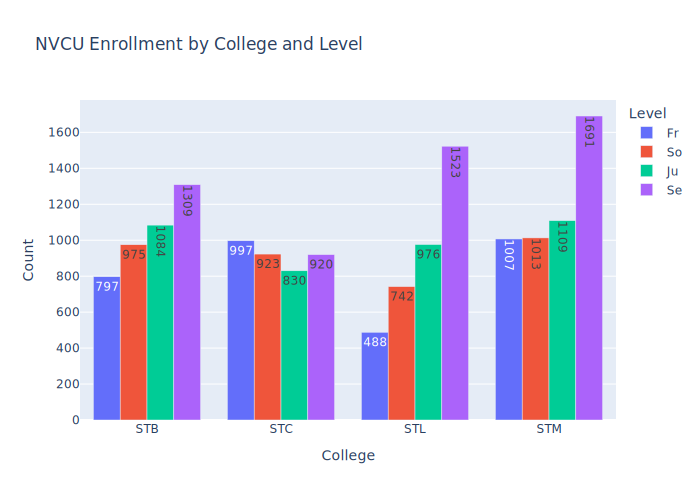

In [27]:
fig_enrollment_by_college_and_level = px.bar(
    df_enrollment_by_college_and_level, 
       x = 'College', y = 'Count', color = 'Level',
      barmode = 'group',
      text_auto = '.0f',
      title = 'NVCU Enrollment by College and Level')
fig_enrollment_by_college_and_level